# Zweig Breadth Thrust — a quantitative teardown 🔬
### Thrust detection on a breadth proxy · conditional vs unconditional forward returns · a Welch *t* + placebo randomization null · costs · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Never_wrong%3F: Busted](https://img.shields.io/badge/Never_wrong%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "never wrong" fuses: a **real but small** post-thrust drift from the **unconditional up-drift** of US equities, and we confront both with the **sample size**. The decisive object is not the point estimate (it's positive, as the lore says) but its **power**: with ~a dozen lifetime events, the excess return is statistically indistinguishable from drawing the same number of random dates.

> ⚠️ **Data + proxy note.** True NYSE advance/decline breadth isn't on yfinance; we build a transparent **proxy** — the daily share advancing across a fixed 40-name large-cap basket (narrower/noisier than NYSE, and survivorship-tilted; both named on the Signal axis). Real data: yfinance daily adjusted closes, SPY + basket, 1995→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zweig_breadth_thrust import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
EVENTS = st.detect_thrusts(F) if HAVE_REAL else None
print("real breadth-proxy cache present:", HAVE_REAL,
      "| thrust events:", (0 if EVENTS is None else len(EVENTS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-04', 'end': '2026-06-22', 'days': 7918, 'years': 31.5, 'n_events': 22, 'h3': (3, 22, 2.37, 59, 2.93, 71, -0.37, 0.644), 'h6': (6, 22, 6.18, 73, 5.89, 76, 0.13, 0.461), 'h12': (12, 22, 14.99, 91, 12.01, 81, 0.94, 0.207), 'net': [(3, 2.37, 2.32), (6, 6.18, 6.13), (12, 14.99, 14.94)], 'robust': [(0.61, 22, 15.1, 0.99, 0.197), (0.615, 22, 15.0, 0.94, 0.207), (0.65, 15, 15.5, 0.68, 0.22)], 'syn': [(0.0, 15, 8.84, 4.98, 1.19, 0.093), (0.1, 15, 17.3, 7.38, 3.18, 0.001)]}


real breadth-proxy cache present: True | thrust events: 22


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 12-month conditional mean **+15.0%** vs base **+12.0%**; Welch **t = 0.94**, placebo **p = 0.21** — positive but **fails t ≥ 2**, and the 3-month *t* is **-0.37** (sign flip). |
| **Tradability** | `FRAGILE` | **22 events in 32y** (≈ one / 1.4y; true NYSE ≈ one / decade). Net of 5-bps costs the per-trade number is intact — **frequency**, not cost, kills it. |
| **Never wrong?** | `BUSTED` | The 12m win-rate **91%** vs an unconditional **81%** — the 'perfect record' is base rate × rarity. Study 167 (Hindenburg) inverted. |

> 💡 In plain words: the thrust really does precede gains — because *almost everything* precedes gains in an up-drifting market. Strip the base rate and ~a dozen events leave nothing the null can't explain.

## 1 · The claim, steelmanned

Let $a_t$ be the advance ratio (advancers / (advancers + decliners)) and $e_t = \mathrm{EMA}_{10}(a_t)$. A **thrust** completes at $t$ iff $e_t > 0.615$ and $\exists\,s \in [t-10, t]:\ e_s < 0.40$ (one event per up-leg, 252-day cooldown).

- **H₁ (the signal predicts).** $\mathbb{E}[r_{t\to t+H}\mid \text{thrust}] > \mathbb{E}[r_{t\to t+H}]$ for forward horizon $H$ — a *positive excess* over the base rate.
- **H₂ (it's deployable).** The excess is large and frequent enough, net of costs, to allocate capital to.
- **H₃ ("never wrong").** The high post-thrust win-rate reflects the signal, not the market's unconditional up-drift.

We find **H₁ not rejected but not supported** (positive, $t < 2$, sign-flips at 3m), **H₂ rejected** (≈22 events / 31y), **H₃ rejected** (the win-rate ≈ the base rate). The legend is true exactly where it's uninformative (the market goes up) and unproven exactly where it would pay (a *distinct* edge).

## 2 · So what? — what rides on each answer

The whole teardown is one decomposition: a conditional mean against an unconditional baseline, judged by its **standard error**.

$$\widehat{\Delta}_H = \bar r^{\text{thrust}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{thrust}}/k + s^2_{\text{all}}/N\,}}.$$

With $k \approx 22$, $s_{\text{thrust}}/\sqrt{k}$ is large: even a few-point $\widehat{\Delta}$ drowns in its own SE. A raw **win-rate** is the wrong lens entirely — US 12-month returns are positive ~80% of the time *unconditionally*, so a 91% conditional rate is ≈1 SE of a proportion away from the null. The honest small-sample instrument is a **randomization (placebo) test**: resample $k$ random entry dates and ask how often chance matches the thrust. That number, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Breadth proxy.** Daily share advancing across a fixed 40-name large-cap basket (yfinance adjusted closes, 1995-01-04→2026-06-22, 7,918 days). Explicit **proxy** for NYSE A/D — narrower, noisier, survivorship-tilted (named on the axis).
- **Detector.** $e_t = \mathrm{EMA}_{10}(a_t)$; thrust = first up-cross of 0.615 with a sub-0.40 print in the prior 10 days; 252-day cooldown ⇒ one event per surge.
- **Forward returns.** Enter the close **1 day after** the signal (no look-ahead), hold $H\in\{3,6,12\}$ months; drop events whose horizon overruns the tape.
- **Null #1 (Welch t).** Conditional mean vs the unconditional overlapping-window mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random valid entry dates; $p = \Pr[\text{random-draw mean} \ge \text{thrust mean}]$ — the small-sample workhorse.
- **Costs.** 1-day lag + a 5-bps round-trip on a buy-and-hold trade.
- **Positive control.** A deterministic breadth series with **12 thrusts injected** and a **known** forward edge: the detector must find them, the inference must recover a planted edge **and** must NOT manufacture significance when the true edge is zero.

## 4 · The teardown

### 4a · The point estimates — positive, small, horizon-flipping

Conditional mean forward return with its $\pm$ standard error, against the unconditional base rate (dashed). Positive at 6/12m, *below* base at 3m.

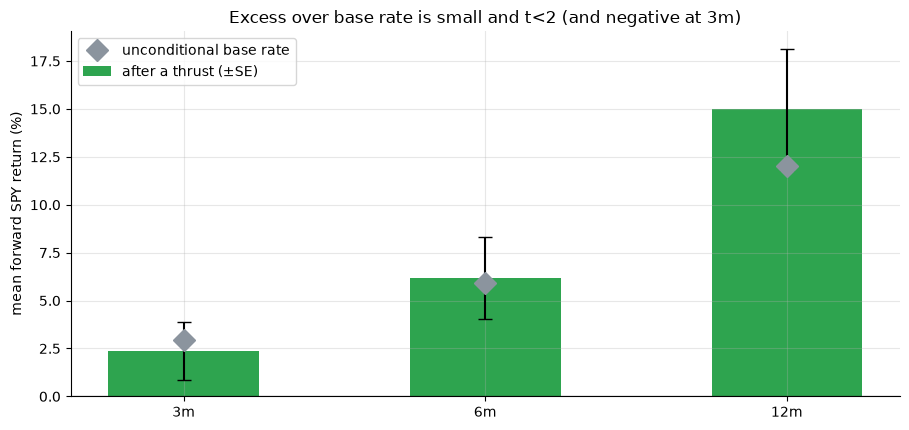

Welch t by horizon: {'3m': -0.37, '6m': 0.13, '12m': 0.94}


In [2]:
hs = [3, 6, 12]
if HAVE_REAL:
    cm, bm, ts = [], [], []
    for m in hs:
        s = st.summarize(F, EVENTS, m); cm.append(s['cond_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        cr = st.event_returns(F, EVENTS, m); s.setdefault('_se', cr.std(ddof=1)/np.sqrt(len(cr)))
    ses = [st.event_returns(F, EVENTS, m).std(ddof=1)/np.sqrt(len(st.event_returns(F, EVENTS, m))) for m in hs]
else:
    cm = [R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h3'][6], R['h6'][6], R['h12'][6]]; ses = [0.035, 0.05, 0.06]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='after a thrust (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward SPY return (%)')
ax.set_title('Excess over base rate is small and t<2 (and negative at 3m)'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: at 12 months the thrust mean is **+15.0%** vs a base **+12.0%** — a ~3-point bump at **t = 0.94** (not significant). At 3 months it's **-0.37** — *below* base. H₁ is **not rejected, not supported**: a positive whisper inside its own error bar that doesn't even keep its sign.

### 4b · The decisive test — a placebo null sized to the event count

Draw 22 *random* entry dates 20,000 times; the histogram is the null distribution of the 12-month mean. The thrust is the green line; the *p*-value is the right-tail mass.

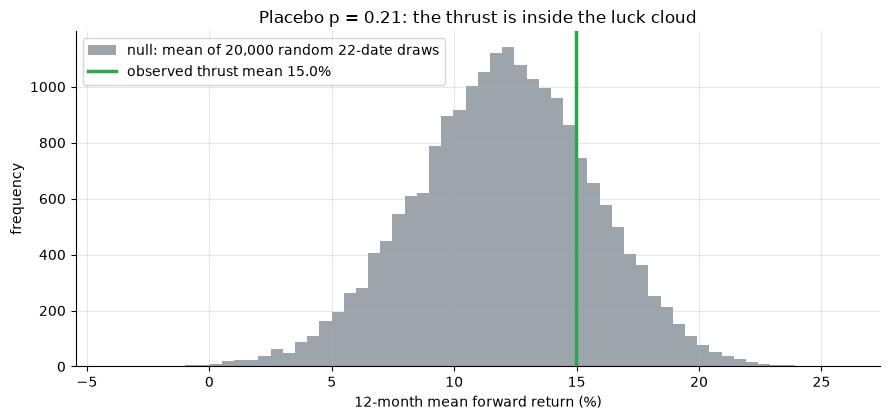

P[random 22-date draw >= thrust] = 0.207  (need <0.05 to call it real; here ~1 in 5)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F, EVENTS, 12); obs = pl['thrust_mean']; pval = pl['p_value']
    h = st.TRADING_DAYS[12]; spy = F['spy'].values; n=len(spy); k=len(EVENTS); lag=1
    vh = n-h-lag-1; fwd = spy[lag+h:lag+h+vh]/spy[lag:lag+vh]-1
    rng = np.random.default_rng(361)
    draws = np.array([fwd[rng.integers(0,vh,size=k)].mean() for _ in range(20000)])
else:
    obs = R['h12'][2]/100; pval = R['h12'][7]
    rng = np.random.default_rng(361); draws = rng.normal(R['h12'][4]/100, 0.045, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: mean of {len(draws):,} random 22-date draws')
ax.axvline(obs*100, c=GREEN, lw=2.5, label=f'observed thrust mean {obs*100:.1f}%')
ax.set_xlabel('12-month mean forward return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the thrust is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random 22-date draw >= thrust] = {pval:.3f}  (need <0.05 to call it real; here ~1 in 5)')

> 💡 In plain words: **21%** of random 22-date samples match or beat the thrust. A real edge would push the green line into the far right tail; instead it sits mid-cloud. This is the crux — **not** a weak point estimate alone, but a point estimate that **a coin could have produced 1 time in 5**. H₃ rejected: the record is base-rate × rarity.

### 4c · Robustness + cost — neither rescues it

Shift the trigger threshold and apply a round-trip cost. The *t* never approaches 2, and 5 bps barely dents a multi-month hold (so cost is **not** the binding constraint — frequency is).

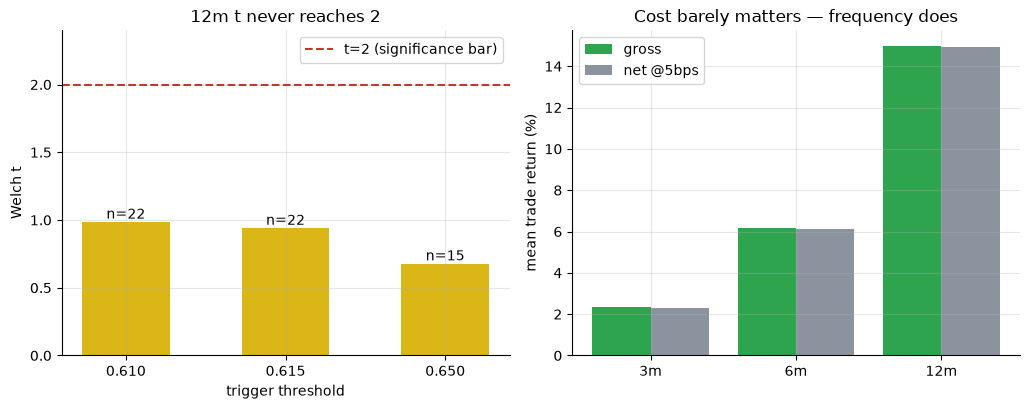

robustness (hi, n, cond12%, t, p): [(0.61, 22, 15.1, 0.99, 0.197), (0.615, 22, 15.0, 0.94, 0.207), (0.65, 15, 15.5, 0.68, 0.22)]


In [4]:
if HAVE_REAL:
    rob = []
    for hi in (0.610, 0.615, 0.650):
        e2 = st.detect_thrusts(F, hi=hi); s = st.summarize(F, e2, 12)
        rob.append((hi, len(e2), s['cond_mean']*100, s['t'], s['p_placebo']))
    netr = [(m,)+ (lambda c: (c['gross_mean']*100, c['net_mean']*100))(st.net_of_costs(F, EVENTS, m, 5.0)) for m in (3,6,12)]
else:
    rob = R['robust']; netr = [(m,g,nn) for (m,g,nn) in R['net']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
his = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
a1.bar([f'{h:.3f}' for h in his], tt, color=AMBER, width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,(t,k) in enumerate(zip(tt,nn)): a1.annotate(f'n={k}',(i,t),ha='center',va='bottom')
a1.set_title('12m t never reaches 2'); a1.set_xlabel('trigger threshold'); a1.set_ylabel('Welch t'); a1.set_ylim(0,2.4); a1.legend()
ms = [r[0] for r in netr]; g = [r[1] for r in netr]; nv = [r[2] for r in netr]; xx=np.arange(len(ms))
a2.bar(xx-.2,g,.4,color=GREEN,label='gross'); a2.bar(xx+.2,nv,.4,color=GREY,label='net @5bps')
a2.set_xticks(xx); a2.set_xticklabels([f'{m}m' for m in ms]); a2.set_ylabel('mean trade return (%)')
a2.set_title('Cost barely matters — frequency does'); a2.legend()
plt.tight_layout(); plt.show()
print('robustness (hi, n, cond12%, t, p):', [(r[0], r[1], round(r[2],1), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: at the canonical 0.65 trigger you get ~15 events (closer to the famed "dozen") and an *even weaker* test; loosening to 0.61 doesn't cross t=2 either. Costs shave a handful of bps off a months-long hold. There is no parameter and no cost regime in which this becomes deployable — **the constraint is the event count itself.**

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic breadth series with **12 thrusts injected**: with **zero** planted edge the test must stay below t=2 (a dozen events can't fake significance); with a **+10%/6m** planted edge it must light up. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large edges.

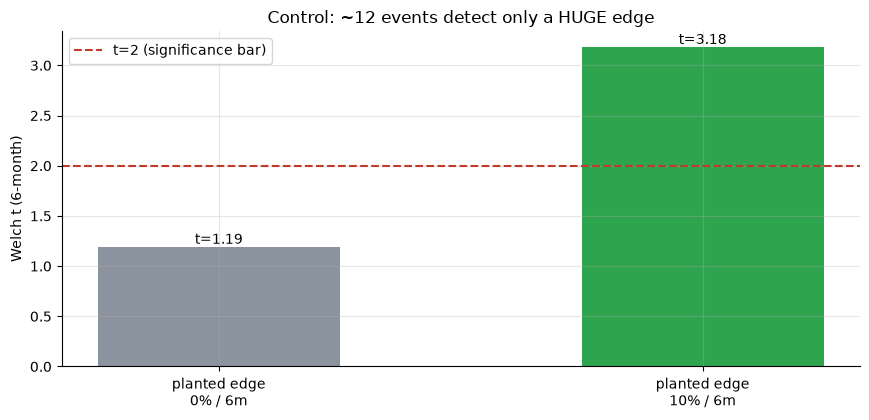

planted +0%/6m: detected=15 cond=8.8% base=5.0% t=1.19 p=0.093
planted +10%/6m: detected=15 cond=17.3% base=7.4% t=3.18 p=0.001


In [5]:
res = []
for edge in (0.0, 0.10):
    syn = data.synthetic_breadth(n_events=12, edge_6m=edge, seed=361)
    ev = st.detect_thrusts(syn, cooldown=120); s = st.summarize(syn, ev, 6)
    res.append((edge, len(ev), s['cond_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / 6m' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (6-month)'); ax.set_title('Control: ~12 events detect only a HUGE edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/6m: detected={k} cond={c:.1f}% base={b:.1f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** real edge the control sits at **t = 1.19** (below 2 — no false positive); only a **+10%/6m** edge — enormous — reaches **t = 3.18**. So the machinery is honest, and the real-tape *t* of ~0.9 is exactly what an *absent or tiny* edge looks like through a 22-event keyhole. The sample size is the verdict.

## 5 · The verdict

- **Signal `WEAK`** — 12m excess **+3.0pp** at Welch **t = 0.94** / placebo **p = 0.21**; 3m *t* = -0.37 (sign flip). Literature support + a positive-but-insignificant, non-robust point estimate ⇒ WEAK, not REAL (the desk's t≥2 bar is not met).
- **Tradability `FRAGILE`** — **22 trades / 32y** (true NYSE ≈ once a decade). Net of 5-bps costs the per-trade number is intact; **frequency**, not cost, makes it un-allocatable. No NAV-scale edge.
- **Never wrong? `BUSTED`** — 12m win-rate **91%** vs unconditional **81%**; the placebo says a coin matches the record ~1 time in 5. A sample-size + base-rate mirage — **Study 167 (Hindenburg) inverted**.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* 12-month excess have to be for a $k$-event study to detect it at t=2? At $k=22$ you'd need an excess several times the one observed; the real signal lives far below the detection floor.

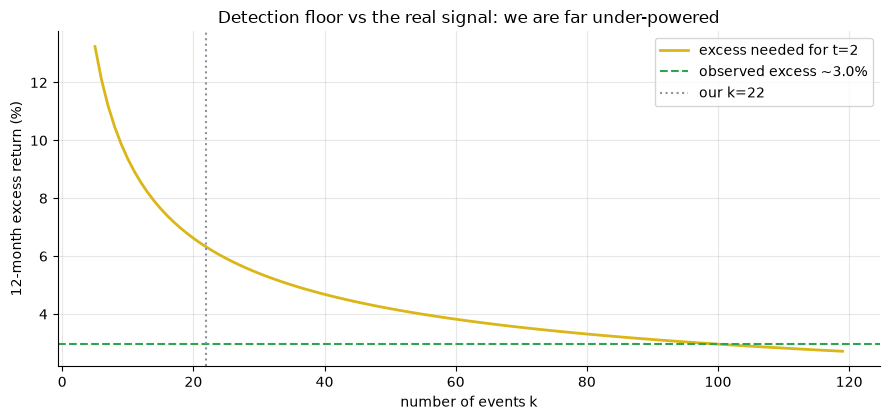

at k=22 you need ~6.3% excess for t=2; observed ~3.0% -> under-powered by ~2.1x


In [6]:
if HAVE_REAL:
    cr = st.event_returns(F, EVENTS, 12); sd = cr.std(ddof=1)
    obs_excess = (R['h12'][2]-R['h12'][4])/100
else:
    sd = 0.16; obs_excess = (R['h12'][2]-R['h12'][4])/100
ks = np.arange(5, 120)
min_detectable = 2.0 * sd / np.sqrt(ks)   # excess needed for t=2 (base SE ~0)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_detectable*100, c=AMBER, lw=2, label='excess needed for t=2')
ax.axhline(obs_excess*100, c=GREEN, ls='--', label=f'observed excess ~{obs_excess*100:.1f}%')
ax.axvline(R['n_events'], c=GREY, ls=':', label=f"our k={R['n_events']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('12-month excess return (%)')
ax.set_title('Detection floor vs the real signal: we are far under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_events'])
print(f'at k={R["n_events"]} you need ~{need*100:.1f}% excess for t=2; observed ~{obs_excess*100:.1f}% -> under-powered by ~{need/obs_excess:.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable excess**; the green line is what we actually see. They don't meet until $k$ is many times larger than the thrust will ever deliver. Even granting the lore a *real* few-point edge, you'd need on the order of a century of additional NYSE thrusts to prove it. There is no sizing, no threshold, no cost assumption that manufactures statistical power from a dozen events — **the rarity that makes the signal romantic is exactly what makes it untestable and untradable.**

## 7 · Going further

- **The inverted twin.** [Study 167 — Hindenburg Omen](../../167-hindenburg-omen/): the same rare-breadth construct pointed at crashes; identical sample-size pathology, opposite narrative. Reading them together is the cleanest demonstration that *rarity itself* defeats inference.
- **Breadth as raw material.** [Study 168 — Advance-Decline](../../168-advance-decline/) — does the A/D line carry information orthogonal to price?
- **Better breadth.** Replace the 40-name proxy with the full S&P 500 (or true NYSE A/D if you have a feed) and a McClellan-style oscillator; the event count and the proxy bias change, the power problem does not.

*The reproducible core is offline and deterministic; the breadth input is an explicit proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*